# Third Medium Contact

In [1]:
import matplotlib.pyplot as plt
import torch
from matplotlib.colors import ListedColormap

from torchfem import Planar
from torchfem.elements import linear_to_quadratic
from torchfem.materials import HyperelasticPlaneStrain
from torchfem.mesh import rect_quad

torch.set_default_dtype(torch.float64)

## Material model

Compressible neo-Hookean energy with Lamé parameters $\mu$ and $\lambda$ from $E$ and $\nu$

$$
\psi = \frac{\mu}{2}(\mathrm{tr}\,\mathbf{C} - 3) - \mu \ln J + \frac{\lambda}{2} \ln^2 J.
$$

Since $\ln J = \frac{1}{2} \ln \det \mathbf{C}$ is blind to the sign of $J$, $\psi$ returns NaN for inverted elements, so the solver cuts back instead of accepting them.

In [2]:
# Material parameters
E = 1000.0
nu = 0.4
lbd = E * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
mu = E / (2.0 * (1.0 + nu))


# Energy function
def psi(F, params):
    """Compressible neo-Hookean energy that becomes NaN once an element inverts."""
    mu = params[..., 0]
    lam = params[..., 1]
    C = F.transpose(-1, -2) @ F
    lnJ = 0.5 * torch.logdet(C)
    trC = C.diagonal(dim1=-2, dim2=-1).sum(-1)
    W = 0.5 * mu * (trC - 3) - mu * lnJ + 0.5 * lam * lnJ**2
    return torch.where(torch.linalg.det(F) > 0, 1.0, torch.nan) * W


# Bulk material: params = [mu, lbd]
material = HyperelasticPlaneStrain(psi, params=[mu, lbd])

## Geometry

A C-shaped cantilever of length $L$ and height $H$ with arms of unit thickness is clamped on the left and pulled down at its top tip. The gap and two element columns beyond its mouth form the third medium.

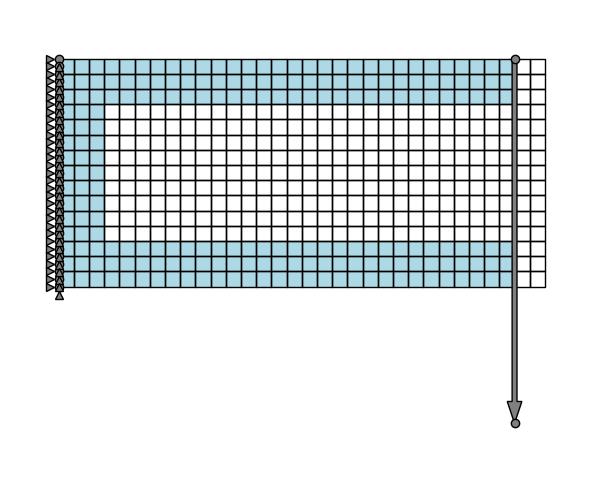

In [3]:
# Dimensions
L = 10.0
H = 5.0

# Create mesh
nodes, elements = rect_quad(33, 16, 32 / 3, H)
nodes, elements = linear_to_quadratic(nodes, elements)

# Create model
cantilever = Planar(nodes, elements, material)

# Create sets
top_tip = torch.isclose(nodes[:, 0], torch.tensor(L)) & (nodes[:, 1] == H)
bottom_tip = torch.isclose(nodes[:, 0], torch.tensor(L)) & (nodes[:, 1] == 1.0)
ec = cantilever.nodes[elements].mean(dim=1)
cutout = (ec[:, 0] > 1.0) & (ec[:, 1] > 1.0) & (ec[:, 1] < 4.0) | (ec[:, 0] > L)

# Load at top tip
cantilever.constraints[top_tip, 1] = True
cantilever.displacements[top_tip, 1] = -8.0

# Constrained displacement at left end
left = nodes[:, 0] == 0.0
cantilever.constraints[left, :] = True

# Show part in light blue and third medium in white
cmap = ListedColormap(["lightblue", "white"])
cantilever.plot(element_property=cutout, cmap=cmap)

## Third medium

The gap and the space beyond the mouth are filled with the bulk material scaled by $\gamma$. This third medium transmits forces only once it is compressed to almost zero volume, but being so soft, it distorts excessively before. Quadratic elements therefore carry the regularization energy [(Bluhm et al. 2021)](https://doi.org/10.1007/s00466-021-01974-x)

$$
\frac{1}{2} k_r \nabla\nabla\mathbf{u} \mathbin{\vdots} \nabla\nabla\mathbf{u}
\quad \text{with} \quad
k_r = \alpha L^2 (\lambda + 2\mu),
$$

scaled by the P-wave modulus of the bulk, for which $\alpha \in [10^{-7}, 10^{-5}]$ is a reasonable range [(Frederiksen et al. 2025)](https://arxiv.org/abs/2512.00133). Larger values help the Newton-Raphson iterations but transmit forces before contact.

In [4]:
# Stiffness scaling of the third medium
gamma = 5e-6

# Regularization of the third medium
alpha = 1e-6
k_r = alpha * L**2 * (lbd + 2.0 * mu)

# Scale the bulk material in the third medium
cantilever.material.params[cutout] = gamma * torch.tensor([mu, lbd])

## Solve

In [5]:
increments = torch.linspace(0.0, 1.0, 151)
# Solve
u, f, σ, F, α = cantilever.solve(
    increments=increments,
    hessian_modulus=k_r * cutout,
    return_intermediate=True,
    verbose=True,
)

----------------------------------------------------------------------------------------
 model    Planar | 480 elem | 3,070 dof | float64
 machine  Apple M1 Pro | 8 threads | 16 GB RAM
 solver   direct | scipy | cpu
 newton   rtol 1e-08 | atol 1e-06 | <=10 it | finite strain
----------------------------------------------------------------------------------------
   Increment   Load factor      Steps  Iterations         Residual   Wall time
           1      0.006667          1           7         2.01e-12      0.40 s
           2       0.01333          1           2         2.22e-12      0.13 s
           3          0.02          1           2         2.17e-12      0.13 s
           4       0.02667          1           2         2.06e-12      0.14 s
           5       0.03333          1           2         2.06e-12      0.12 s
           6          0.04          1           2         1.90e-12      0.12 s
           7       0.04667          1           2         1.97e-12      0.12 s
  

## Results

The reference is a node-to-segment contact solution of the same problem [(Faltus et al. 2026, Fig. 1b)](https://arxiv.org/abs/2603.13063).

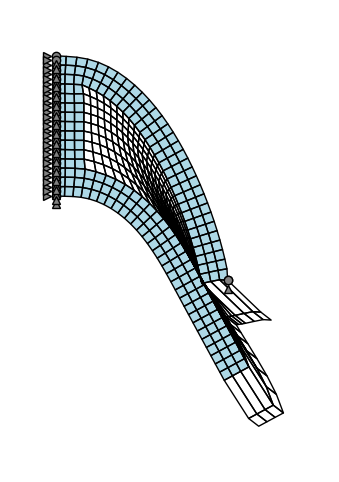

In [6]:
# Plot
cantilever.plot(u[-1], element_property=cutout, cmap=cmap)

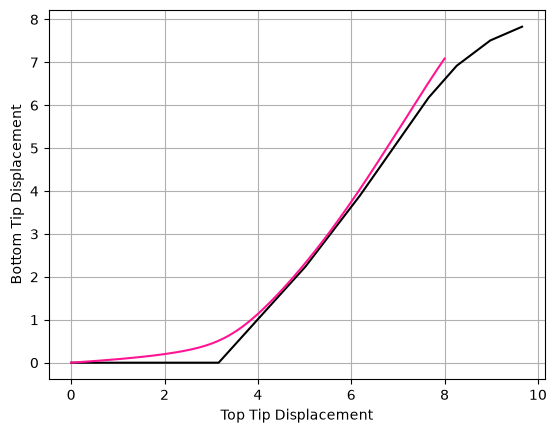

In [7]:
reference = torch.tensor(
    [
        [0.0, 0.0],
        [3.16, 0.0],
        [5.02, 2.24],
        [6.19, 3.90],
        [7.66, 6.18],
        [8.26, 6.92],
        [8.98, 7.51],
        [9.66, 7.83],
    ]
)


plt.plot(reference[:, 0], reference[:, 1], color="black", label="Reference")
plt.plot(-u[:, top_tip, 1], -u[:, bottom_tip, 1], color="deeppink", label="torch-fem")
plt.xlabel("Top Tip Displacement")
plt.ylabel("Bottom Tip Displacement")
plt.grid()
plt.show()